In [160]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [161]:
df = pd.read_csv(r"C:\Users\vedan\PycharmProjects\AI-ML\Day 2 - Assesment difficulty prediction\data\student_assessment_dataset.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (5000, 13)


,student_id,study_hours_per_week,hours_studied_for_assessment,study_sessions_last_30_days,engagement_score,previous_scores,avg_previous_score,days_since_last_study,avg_attempts_per_assessment,question_difficulty,difficulty_score,learning_velocity,passed
0,1,12.881202,7.964516,11.426307,78.482862,76.814937,68.038282,1,3,medium,2,-8.229587,1
1,2,12.732929,9.083502,11.869376,77.833236,68.402106,64.120886,3,2,medium,2,-0.946706,1
2,3,6.021784,8.207857,12.257180,65.634802,75.616487,75.424149,14,3,medium,2,-0.459076,0
3,4,13.349549,10.331254,15.787446,80.795842,88.263725,88.875034,12,2,easy,1,1.692599,1
4,5,18.664145,13.591536,9.011131,60.099173,69.644368,71.286809,5,4,medium,2,4.772185,1


In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   student_id                    5000 non-null   int64  
 1   study_hours_per_week          5000 non-null   float64
 2   hours_studied_for_assessment  5000 non-null   float64
 3   study_sessions_last_30_days   5000 non-null   float64
 4   engagement_score              5000 non-null   float64
 5   previous_scores               5000 non-null   float64
 6   avg_previous_score            5000 non-null   float64
 7   days_since_last_study         5000 non-null   int64  
 8   avg_attempts_per_assessment   5000 non-null   int64  
 9   question_difficulty           5000 non-null   object 
 10  difficulty_score              5000 non-null   int64  
 11  learning_velocity             5000 non-null   float64
 12  passed                        5000 non-null   int64  
dtypes: 

In [163]:
df.describe()

,student_id,study_hours_per_week,hours_studied_for_assessment,study_sessions_last_30_days,engagement_score,previous_scores,avg_previous_score,days_since_last_study,avg_attempts_per_assessment,difficulty_score,learning_velocity,passed
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,2500.500000,14.956407,10.032646,12.070726,74.804870,69.976250,69.985720,7.542600,2.482000,2.203800,-0.010312,0.62700
std,1443.520003,5.034034,2.993190,3.999075,9.799862,12.726057,12.537086,4.001273,1.117464,0.921974,6.815967,0.48365
min,1.000000,1.000000,1.000000,1.000000,38.449135,24.644561,27.745069,1.000000,1.000000,1.000000,-33.160251,0.00000
25%,1250.750000,11.567085,8.017341,9.341277,67.982399,61.520627,61.716488,4.000000,1.000000,2.000000,-4.474529,0.00000
50%,2500.500000,14.912747,10.029752,12.077037,74.919832,70.025795,70.037984,8.000000,2.000000,2.000000,-0.027505,1.00000
75%,3750.250000,18.386190,12.026603,14.826459,81.506064,78.621320,78.460963,11.000000,3.000000,3.000000,4.480989,1.00000
max,5000.000000,32.645276,20.286731,29.916337,100.000000,100.000000,100.000000,14.000000,4.000000,4.000000,30.473217,1.00000


In [164]:
df.isnull().sum()

student_id                      0
study_hours_per_week            0
hours_studied_for_assessment    0
study_sessions_last_30_days     0
engagement_score                0
previous_scores                 0
avg_previous_score              0
days_since_last_study           0
avg_attempts_per_assessment     0
question_difficulty             0
difficulty_score                0
learning_velocity               0
passed                          0
dtype: int64

## Handle Missing Values

In [165]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

## One Hot Encoding

In [166]:
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df[['question_difficulty']])

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['question_difficulty']))

encoded_df.reset_index(drop=True, inplace=True)
df.reset_index(drop=True, inplace=True)

df = pd.concat([df, encoded_df], axis=1)

df.drop('question_difficulty', axis=1, inplace=True)

# Feature Engineering

## Study Related Features

In [167]:
study_cols = ['study_hours_per_week', 'hours_studied_for_assessment', 'study_sessions_last_30_days', 'days_since_last_study']

df['total_study_effort'] = df[study_cols].sum(axis=1)
df['avg_study_effort'] = df[study_cols].mean(axis=1)
df['study_consistency'] = df[study_cols].std(axis=1)
df['max_study_effort'] = df[study_cols].max(axis=1)
df['min_study_effort'] = df[study_cols].min(axis=1)
df.head()

,student_id,study_hours_per_week,hours_studied_for_assessment,study_sessions_last_30_days,engagement_score,previous_scores,avg_previous_score,days_since_last_study,avg_attempts_per_assessment,difficulty_score,learning_velocity,passed,question_difficulty_easy,question_difficulty_hard,question_difficulty_medium,question_difficulty_very_hard,total_study_effort,avg_study_effort,study_consistency,max_study_effort,min_study_effort
0,1,12.881202,7.964516,11.426307,78.482862,76.814937,68.038282,1,3,2,-8.229587,1,0.0,0.0,1.0,0.0,33.272025,8.318006,5.296617,12.881202,1.000000
1,2,12.732929,9.083502,11.869376,77.833236,68.402106,64.120886,3,2,2,-0.946706,1,0.0,0.0,1.0,0.0,36.685807,9.171452,4.399147,12.732929,3.000000
2,3,6.021784,8.207857,12.257180,65.634802,75.616487,75.424149,14,3,2,-0.459076,0,0.0,0.0,1.0,0.0,40.486820,10.121705,3.654841,14.000000,6.021784
3,4,13.349549,10.331254,15.787446,80.795842,88.263725,88.875034,12,2,1,1.692599,1,1.0,0.0,0.0,0.0,51.468249,12.867062,2.305324,15.787446,10.331254
4,5,18.664145,13.591536,9.011131,60.099173,69.644368,71.286809,5,4,2,4.772185,1,0.0,0.0,1.0,0.0,46.266812,11.566703,5.891411,18.664145,5.000000


## Score Related Features

In [168]:
score_cols = ['avg_previous_score', 'previous_scores', 'difficulty_score', 'engagement_score']

df['ability_score'] = df[score_cols].mean(axis=1)
df['total_score'] = df[score_cols].sum(axis=1)
df['score_consistency'] = df[score_cols].std(axis=1)
df['max_score'] = df[score_cols].max(axis=1)
df['min_score'] = df[score_cols].min(axis=1)
df.head()

,student_id,study_hours_per_week,hours_studied_for_assessment,study_sessions_last_30_days,engagement_score,previous_scores,avg_previous_score,days_since_last_study,avg_attempts_per_assessment,difficulty_score,learning_velocity,passed,question_difficulty_easy,question_difficulty_hard,question_difficulty_medium,question_difficulty_very_hard,total_study_effort,avg_study_effort,study_consistency,max_study_effort,min_study_effort,ability_score,total_score,score_consistency,max_score,min_score
0,1,12.881202,7.964516,11.426307,78.482862,76.814937,68.038282,1,3,2,-8.229587,1,0.0,0.0,1.0,0.0,33.272025,8.318006,5.296617,12.881202,1.000000,56.334020,225.336082,36.511253,78.482862,2.0
1,2,12.732929,9.083502,11.869376,77.833236,68.402106,64.120886,3,2,2,-0.946706,1,0.0,0.0,1.0,0.0,36.685807,9.171452,4.399147,12.732929,3.000000,53.089057,212.356227,34.537694,77.833236,2.0
2,3,6.021784,8.207857,12.257180,65.634802,75.616487,75.424149,14,3,2,-0.459076,0,0.0,0.0,1.0,0.0,40.486820,10.121705,3.654841,14.000000,6.021784,54.668859,218.675437,35.420549,75.616487,2.0
3,4,13.349549,10.331254,15.787446,80.795842,88.263725,88.875034,12,2,1,1.692599,1,1.0,0.0,0.0,0.0,51.468249,12.867062,2.305324,15.787446,10.331254,64.733650,258.934601,42.647560,88.875034,1.0
4,5,18.664145,13.591536,9.011131,60.099173,69.644368,71.286809,5,4,2,4.772185,1,0.0,0.0,1.0,0.0,46.266812,11.566703,5.891411,18.664145,5.000000,50.757587,203.030350,32.877180,71.286809,2.0


## Advanced Engineered Features

In [169]:
# Preparedness score
df['preparedness_score'] = (
    df['ability_score'] * 0.7 +
    df['avg_study_effort'] * 0.3
)

# Study efficiency
df['study_efficiency'] = (
    df['ability_score'] /
    (df['avg_study_effort'] + 1)
)

# Performance stability
df['performance_stability'] = (
    1 / (df['score_consistency'] + 1)
)

df.head()

,student_id,study_hours_per_week,hours_studied_for_assessment,study_sessions_last_30_days,engagement_score,previous_scores,avg_previous_score,days_since_last_study,avg_attempts_per_assessment,difficulty_score,learning_velocity,passed,question_difficulty_easy,question_difficulty_hard,question_difficulty_medium,question_difficulty_very_hard,total_study_effort,avg_study_effort,study_consistency,max_study_effort,min_study_effort,ability_score,total_score,score_consistency,max_score,min_score,preparedness_score,study_efficiency,performance_stability
0,1,12.881202,7.964516,11.426307,78.482862,76.814937,68.038282,1,3,2,-8.229587,1,0.0,0.0,1.0,0.0,33.272025,8.318006,5.296617,12.881202,1.000000,56.334020,225.336082,36.511253,78.482862,2.0,41.929216,6.045716,0.026659
1,2,12.732929,9.083502,11.869376,77.833236,68.402106,64.120886,3,2,2,-0.946706,1,0.0,0.0,1.0,0.0,36.685807,9.171452,4.399147,12.732929,3.000000,53.089057,212.356227,34.537694,77.833236,2.0,39.913775,5.219418,0.028139
2,3,6.021784,8.207857,12.257180,65.634802,75.616487,75.424149,14,3,2,-0.459076,0,0.0,0.0,1.0,0.0,40.486820,10.121705,3.654841,14.000000,6.021784,54.668859,218.675437,35.420549,75.616487,2.0,41.304713,4.915511,0.027457
3,4,13.349549,10.331254,15.787446,80.795842,88.263725,88.875034,12,2,1,1.692599,1,1.0,0.0,0.0,0.0,51.468249,12.867062,2.305324,15.787446,10.331254,64.733650,258.934601,42.647560,88.875034,1.0,49.173674,4.668159,0.022911
4,5,18.664145,13.591536,9.011131,60.099173,69.644368,71.286809,5,4,2,4.772185,1,0.0,0.0,1.0,0.0,46.266812,11.566703,5.891411,18.664145,5.000000,50.757587,203.030350,32.877180,71.286809,2.0,39.000322,4.039054,0.029518


## Correlation Analysis

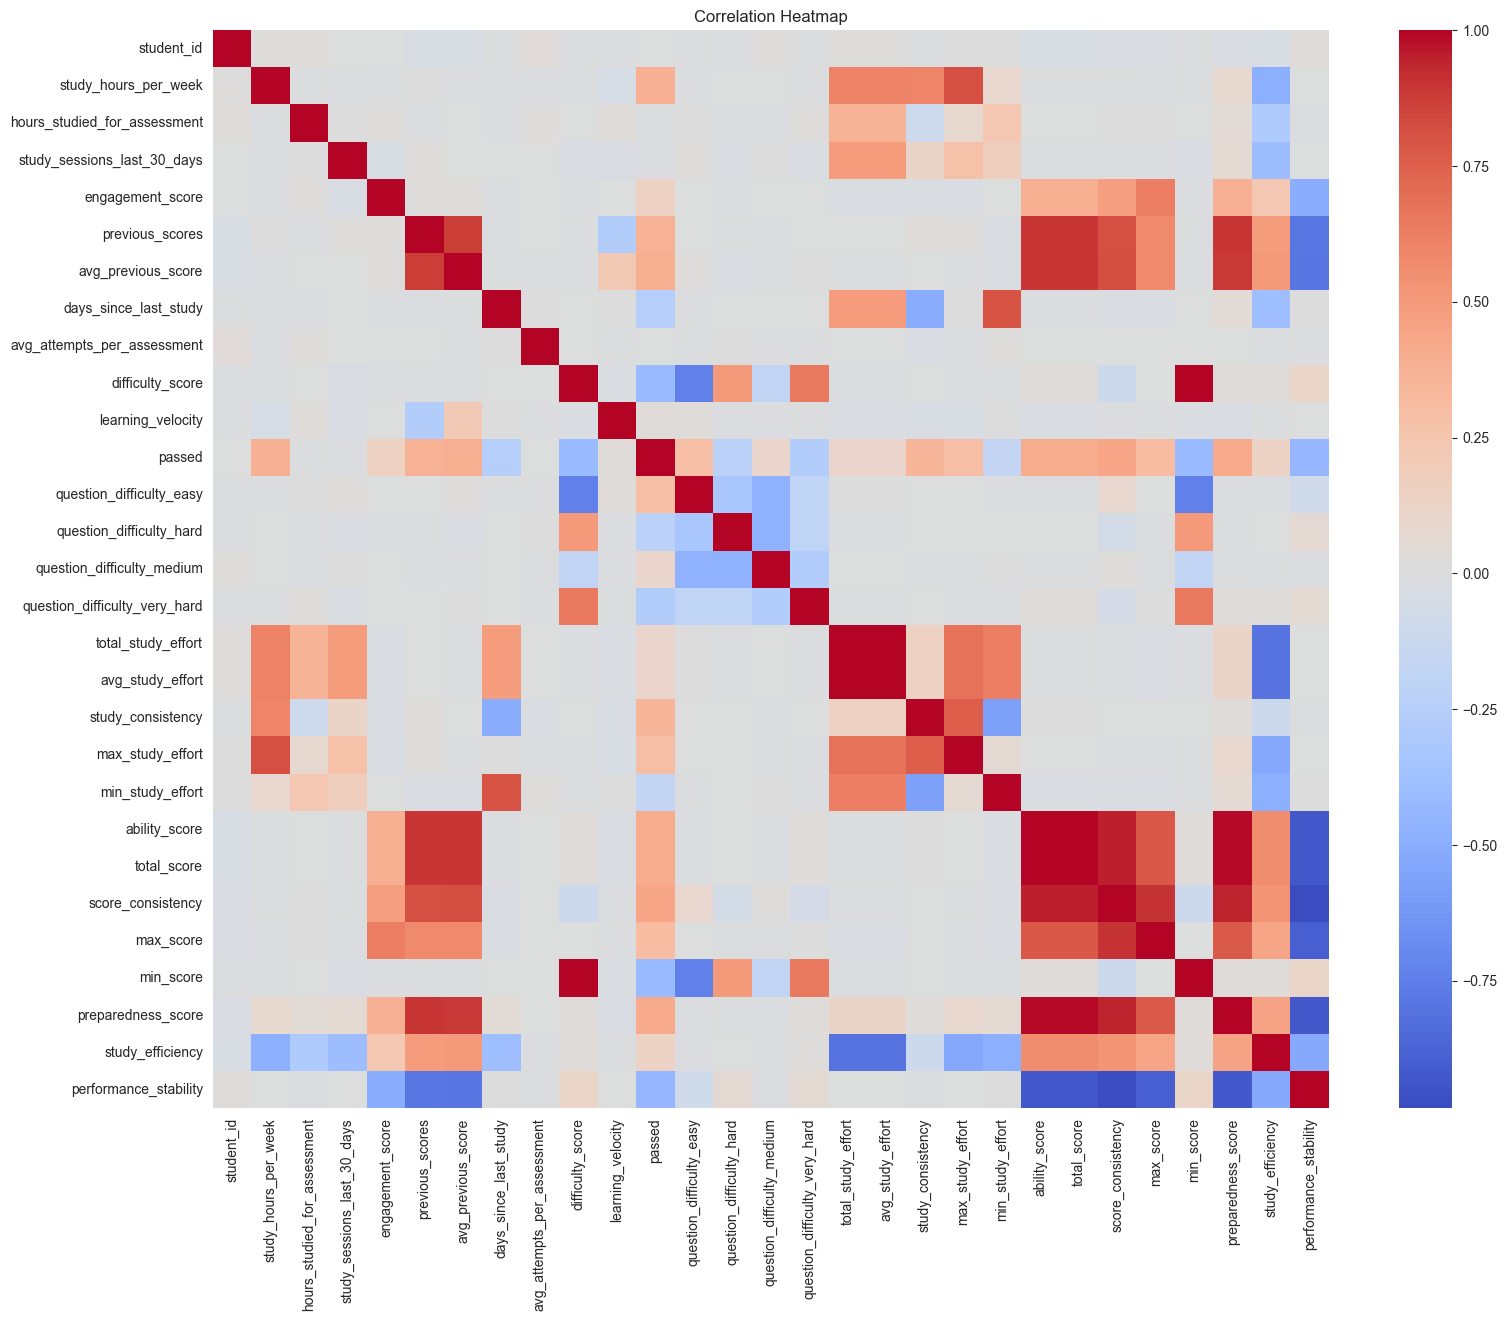

In [170]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()


## Final Dataset Overview

In [171]:
print("Final Dataset Shape:", df.shape)
df.head()

Final Dataset Shape: (5000, 29)


,student_id,study_hours_per_week,hours_studied_for_assessment,study_sessions_last_30_days,engagement_score,previous_scores,avg_previous_score,days_since_last_study,avg_attempts_per_assessment,difficulty_score,learning_velocity,passed,question_difficulty_easy,question_difficulty_hard,question_difficulty_medium,question_difficulty_very_hard,total_study_effort,avg_study_effort,study_consistency,max_study_effort,min_study_effort,ability_score,total_score,score_consistency,max_score,min_score,preparedness_score,study_efficiency,performance_stability
0,1,12.881202,7.964516,11.426307,78.482862,76.814937,68.038282,1,3,2,-8.229587,1,0.0,0.0,1.0,0.0,33.272025,8.318006,5.296617,12.881202,1.000000,56.334020,225.336082,36.511253,78.482862,2.0,41.929216,6.045716,0.026659
1,2,12.732929,9.083502,11.869376,77.833236,68.402106,64.120886,3,2,2,-0.946706,1,0.0,0.0,1.0,0.0,36.685807,9.171452,4.399147,12.732929,3.000000,53.089057,212.356227,34.537694,77.833236,2.0,39.913775,5.219418,0.028139
2,3,6.021784,8.207857,12.257180,65.634802,75.616487,75.424149,14,3,2,-0.459076,0,0.0,0.0,1.0,0.0,40.486820,10.121705,3.654841,14.000000,6.021784,54.668859,218.675437,35.420549,75.616487,2.0,41.304713,4.915511,0.027457
3,4,13.349549,10.331254,15.787446,80.795842,88.263725,88.875034,12,2,1,1.692599,1,1.0,0.0,0.0,0.0,51.468249,12.867062,2.305324,15.787446,10.331254,64.733650,258.934601,42.647560,88.875034,1.0,49.173674,4.668159,0.022911
4,5,18.664145,13.591536,9.011131,60.099173,69.644368,71.286809,5,4,2,4.772185,1,0.0,0.0,1.0,0.0,46.266812,11.566703,5.891411,18.664145,5.000000,50.757587,203.030350,32.877180,71.286809,2.0,39.000322,4.039054,0.029518


## Target Distribution

In [172]:
df['passed'].value_counts(normalize=True)

passed
1    0.627
0    0.373
Name: proportion, dtype: float64

## Final Feature List

In [173]:
print(df.columns.tolist())

['student_id', 'study_hours_per_week', 'hours_studied_for_assessment', 'study_sessions_last_30_days', 'engagement_score', 'previous_scores', 'avg_previous_score', 'days_since_last_study', 'avg_attempts_per_assessment', 'difficulty_score', 'learning_velocity', 'passed', 'question_difficulty_easy', 'question_difficulty_hard', 'question_difficulty_medium', 'question_difficulty_very_hard', 'total_study_effort', 'avg_study_effort', 'study_consistency', 'max_study_effort', 'min_study_effort', 'ability_score', 'total_score', 'score_consistency', 'max_score', 'min_score', 'preparedness_score', 'study_efficiency', 'performance_stability']


In [174]:
df.to_csv("cleaned_student_assessment_data.csv", index=False)